# 03: Doubly Robust Estimation

The goal is to estimate the effect of top-3 ranking on clicks using a doubly robust estimator.

Notebook 1 showed the raw rank-position pattern. Notebook 2 adjusted for observed confounding using inverse propensity weighting (IPW). This notebook goes one step further by combining two models:

- A **propensity model** for treatment assignment: `P(is_top_3 = 1 | X)`.
- An **outcome model** for click probability: `E(clicked | is_top_3, X)`.

The doubly robust estimator is useful because it can remain consistent if either the propensity model or the outcome model is correctly specified, under the usual causal assumptions.

<!-- dataset-experiment-context -->
## Dataset and Design Context

This project uses the Microsoft News Dataset (MIND) impression logs. The working table is an impression-item panel: each row is one news item displayed inside a user impression slate.

This is a real observational ranking log, not a randomized ranking experiment. The treatment is top-3 exposure, the outcome is click-through, and the main causal risk is that the production ranker likely used relevance, freshness, and intent signals that are not fully observed in the public data.

The project should therefore be read as an offline causal measurement and experiment-prioritization workflow. Naive rank-position click differences are descriptive. Adjusted estimates, overlap checks, heterogeneous effects, and policy simulations are used to decide what would be credible enough to test online.

**Role of this notebook.** This notebook combines treatment and outcome models in a doubly robust AIPW estimator so the average top-3 effect can be audited against IPW and outcome-regression benchmarks.

<!-- mathematical-setup -->

## Mathematical Setup

Doubly robust estimation combines a propensity model with outcome models. Let

$$
e(X_i)=\Pr(T_i=1\mid X_i), \qquad
\mu_t(X_i)=\mathbb{E}[Y_i\mid T_i=t, X_i].
$$

The augmented inverse-probability weighted score for the average effect is

$$
\widehat{\tau}_{\text{AIPW}}=
\frac{1}{n}\sum_{i=1}^n
\left[
\widehat\mu_1(X_i)-\widehat\mu_0(X_i)
+\frac{T_i\{Y_i-\widehat\mu_1(X_i)\}}{\widehat e(X_i)}
-\frac{(1-T_i)\{Y_i-\widehat\mu_0(X_i)\}}{1-\widehat e(X_i)}
\right].
$$

The estimator is called doubly robust because it remains consistent if either the propensity model or the outcome model is correctly specified, along with the usual identification conditions. Cross-fitting keeps the nuisance predictions out of sample so the final estimate is less tied to overfitting in the nuisance models.


## Causal Setup

We keep the same first treatment definition as notebook 2:

- **Treatment** `T`: `is_top_3 = 1`, meaning a displayed item appears in rank positions 1, 2, or 3.
- **Control**: `is_top_3 = 0`, meaning a displayed item appears below position 3.
- **Outcome** `Y`: `clicked`, meaning whether the user clicked the displayed item.
- **Covariates** `X`: observed user, item, and context features available in the processed table.

The estimand is the average treatment effect (ATE):

`E[Y(1) - Y(0)]`

In plain English: the average change in click probability if a displayed item were moved into the top 3 versus shown lower in the ranking, after adjusting for observed covariates.

This is still an observational causal estimate. It relies on assumptions like no unobserved confounding, reasonable overlap, and good-enough nuisance models.

#### Setup

This cell imports the libraries used in the doubly robust workflow. We use pandas and numpy for data manipulation, seaborn/matplotlib for diagnostics, and scikit-learn for preprocessing and model fitting. `clone` is used during cross-fitting so each fold gets a fresh model instance.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

This cell prepares the notebook environment for doubly robust AIPW estimation. There is no substantive model result yet; the important outcome is that the imports and display settings are ready so the next cells can focus on the data and causal question.


#### Load The Processed Data

This cell finds the project root, loads the processed MIND-small impression table, and prints its shape. The processed file has one row per displayed news item, which is the unit of analysis for this rank-position project.

In [2]:
DATA_RELATIVE_PATH = Path("data/processed/mind_small_impressions_train_sample.parquet")
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / DATA_RELATIVE_PATH).exists()
)

DATA_PATH = PROJECT_ROOT / DATA_RELATIVE_PATH
df = pd.read_parquet(DATA_PATH)

df.shape

(737762, 20)

The loaded table preview and shape confirm that the notebook is using the expected processed dataset. This check anchors the rest of the analysis, because all treatment, outcome, and covariate definitions depend on these columns being present and correctly typed.


#### Modeling Sample

Doubly robust estimation is more expensive than notebook 2 because we cross-fit both propensity and outcome models. Cross-fitting means we repeatedly train models on one part of the data and predict on held-out rows.

For an interactive notebook, we use a moderately sized random sample. Once the workflow is stable, the same logic can be run on a larger processed table.

#### Create Analysis Columns

This cell samples rows for modeling and creates explicit analysis columns. `treatment` is the binary top-3 indicator, `outcome` is the click indicator, and `log_item_exposures` is a log-transformed exposure count used as a simple popularity proxy. The treatment label is only for readable tables and plots.

In [3]:
MODEL_SAMPLE_SIZE = 150_000
RANDOM_STATE = 42

model_df = (
    df.sample(n=min(len(df), MODEL_SAMPLE_SIZE), random_state=RANDOM_STATE)
    .reset_index(drop=True)
    .copy()
)
model_df["treatment"] = model_df["is_top_3"].astype(int)
model_df["outcome"] = model_df["clicked"].astype(int)
model_df["log_item_exposures"] = np.log1p(model_df["item_exposures"])
model_df["treatment_label"] = np.where(model_df["treatment"] == 1, "top_3", "rank_4_plus")

model_df[["treatment", "outcome", "rank_position"]].describe()

,treatment,outcome,rank_position
count,150000.0000,150000.0000,150000.0000
mean,0.0801,0.0396,38.7516
std,0.2714,0.1949,37.5481
min,0.0000,0.0000,1.0000
25%,0.0000,0.0000,11.0000
50%,0.0000,0.0000,27.0000
75%,0.0000,0.0000,55.0000
max,1.0000,1.0000,287.0000


This cell defines the working analysis sample and standardizes treatment/outcome columns. Fixing this sample early keeps later model comparisons fair because each estimator works on the same rows and target definition.


### Feature Design

The doubly robust estimator uses two nuisance models, and both need covariates. The propensity model predicts treatment assignment from covariates. The outcome model predicts clicks from treatment plus covariates.

We avoid using `item_clicks` and `item_ctr` as model inputs here because they are computed using clicks from the same sample. Those features are useful for EDA and can leak outcome information into the modeling step. `log_item_exposures` is safer as a first-pass popularity proxy because it is based on exposure count.

#### Define Covariate Sets

This cell defines the covariates used by the nuisance models. Numeric features and categorical features are separated because they require different preprocessing. The propensity model uses only `X`; the outcome model uses `X` plus the treatment indicator.

In [4]:
numeric_features = [
    "history_len",
    "candidate_set_size",
    "title_length",
    "abstract_length",
    "hour",
    "day_of_week",
    "log_item_exposures",
]
categorical_features = ["category", "subcategory"]

propensity_features = numeric_features + categorical_features
outcome_numeric_features = numeric_features + ["treatment"]
outcome_features = outcome_numeric_features + categorical_features

X = model_df[propensity_features]
t = model_df["treatment"]
y = model_df["outcome"]

pd.Series(
    {
        "rows": len(model_df),
        "treatment_rate_top_3": t.mean(),
        "outcome_rate_clicked": y.mean(),
    }
)

rows                   150000.0000
treatment_rate_top_3        0.0801
outcome_rate_clicked        0.0396
dtype: float64

This output is part of the doubly robust AIPW estimation workflow. Read it as a checkpoint: it either verifies an input, defines reusable analysis machinery, or produces a diagnostic that motivates the next step in the notebook.


#### Model Pipelines

Both nuisance models use the same general preprocessing pattern:

- Numeric features are median-imputed and standardized.
- Categorical features are imputed and one-hot encoded.
- Rare categorical levels are grouped using `min_frequency` so the model does not create many extremely sparse columns.

We use logistic regression for this first doubly robust notebook because it is transparent, fast, and produces probabilities directly. A later version could replace these with LightGBM or XGBoost.

#### Build Reusable Model Pipelines

This cell defines helper functions that create fresh preprocessing and logistic-regression pipelines. Fresh pipelines are important for cross-fitting because each fold must train its own model without carrying fitted state from another fold.

In [5]:
# Build reusable model pipelines.
def make_preprocessor(numeric_cols, categorical_cols):
    """
    Build the shared preprocessing transformer for causal nuisance models.
    
    Idea
    ----
    Numeric columns are imputed and scaled when appropriate, while categorical columns are imputed and one-hot encoded so downstream propensity and outcome models receive a consistent design matrix.
    
    Parameters
    ----------
    numeric_cols : object
        Numeric covariate columns used by the model.
    categorical_cols : object
        Categorical covariate columns used by the model.
    
    Returns
    -------
    sklearn.compose.ColumnTransformer
        Configured preprocessing transformer for the specified numeric and categorical columns.
    """
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=50,
                    sparse_output=True,
                ),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ]
    )


def make_logistic_pipeline(numeric_cols, categorical_cols):
    """
    Build a logistic-regression propensity pipeline.
    
    Idea
    ----
    The pipeline combines project-specific preprocessing with a logistic model so top-rank exposure or treatment assignment can be estimated from observed covariates.
    
    Parameters
    ----------
    numeric_cols : object
        Numeric covariate columns used by the model.
    categorical_cols : object
        Categorical covariate columns used by the model.
    
    Returns
    -------
    sklearn.pipeline.Pipeline
        Pipeline that preprocesses covariates and fits a logistic treatment model.
    """
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor(numeric_cols, categorical_cols)),
            (
                "model",
                LogisticRegression(
                    max_iter=500,
                    solver="lbfgs",
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


base_propensity_model = make_logistic_pipeline(numeric_features, categorical_features)
base_outcome_model = make_logistic_pipeline(outcome_numeric_features, categorical_features)

This cell creates reusable modeling machinery for later estimates. The value is consistency. The same preprocessing and helper functions can be applied across folds, estimators, and sensitivity checks.


### Cross-Fit Nuisance Models

AIPW needs three predictions for every row:

- `e_hat`: estimated propensity score, `P(T = 1 | X)`.
- `mu1_hat`: estimated click probability if the row were treated, `E[Y | T = 1, X]`.
- `mu0_hat`: estimated click probability if the row were control, `E[Y | T = 0, X]`.

Cross-fitting makes these predictions out-of-fold. That means each row is predicted by models that were not trained on that row. This reduces overfitting bias in the final doubly robust estimate.

#### Generate Out-Of-Fold Propensity And Outcome Predictions

This cell performs 3-fold cross-fitting. In each fold, the models are trained on two-thirds of the sample and used to predict the held-out third. For the outcome model, we create two copies of the held-out rows: one with `treatment = 1` and one with `treatment = 0`. Those two predictions become the estimated potential outcome probabilities `mu1_hat` and `mu0_hat`.

In [6]:
# Generate out-of-fold propensity and outcome predictions.
N_FOLDS = 3
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

e_hat = np.zeros(len(model_df))
mu1_hat = np.zeros(len(model_df))
mu0_hat = np.zeros(len(model_df))

propensity_metrics = []
outcome_metrics = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, t), start=1):
    train_df = model_df.iloc[train_idx]
    valid_df = model_df.iloc[valid_idx]

    propensity_model = clone(base_propensity_model)
    propensity_model.fit(train_df[propensity_features], train_df["treatment"])
    e_valid = propensity_model.predict_proba(valid_df[propensity_features])[:, 1]
    e_hat[valid_idx] = e_valid

    outcome_model = clone(base_outcome_model)
    outcome_model.fit(train_df[outcome_features], train_df["outcome"])

    valid_actual = valid_df[outcome_features]
    y_valid_hat = outcome_model.predict_proba(valid_actual)[:, 1]

    valid_treated = valid_df[propensity_features].copy()
    valid_treated["treatment"] = 1
    valid_treated = valid_treated[outcome_features]

    valid_control = valid_df[propensity_features].copy()
    valid_control["treatment"] = 0
    valid_control = valid_control[outcome_features]

    mu1_hat[valid_idx] = outcome_model.predict_proba(valid_treated)[:, 1]
    mu0_hat[valid_idx] = outcome_model.predict_proba(valid_control)[:, 1]

    propensity_metrics.append(
        {
            "fold": fold,
            "roc_auc": roc_auc_score(valid_df["treatment"], e_valid),
            "average_precision": average_precision_score(valid_df["treatment"], e_valid),
            "brier_score": brier_score_loss(valid_df["treatment"], e_valid),
        }
    )
    outcome_metrics.append(
        {
            "fold": fold,
            "roc_auc": roc_auc_score(valid_df["outcome"], y_valid_hat),
            "average_precision": average_precision_score(valid_df["outcome"], y_valid_hat),
            "brier_score": brier_score_loss(valid_df["outcome"], y_valid_hat),
        }
    )

model_df["e_hat"] = e_hat
model_df["mu1_hat"] = mu1_hat
model_df["mu0_hat"] = mu0_hat

pd.DataFrame(propensity_metrics)

,fold,roc_auc,average_precision,brier_score
0,1,0.7769,0.3407,0.0660
1,2,0.7622,0.3058,0.0668
2,3,0.7661,0.3205,0.0665


Cross-fitting creates out-of-sample nuisance predictions for treatment and outcome models. This reduces overfitting bias and makes the later doubly robust scores more credible. The practical implication is that poor overlap or extreme propensity scores would make the adjusted estimate depend on a narrow slice of comparable observations.


#### Inspect Outcome Model Metrics

This cell displays fold-level metrics for the outcome model. The outcome model predicts clicks, which are relatively rare, so average precision is especially useful. AIPW does not require a perfect click model. It does require useful signal and sensible probabilities.

In [7]:
pd.DataFrame(outcome_metrics)

,fold,roc_auc,average_precision,brier_score
0,1,0.7119,0.1232,0.0363
1,2,0.6934,0.1111,0.0371
2,3,0.7098,0.1132,0.0368


The nuisance-model metrics show how well the supporting prediction models perform. Weak nuisance models can make IPW, DR, and policy estimates less reliable, so these diagnostics help judge the stability of the causal workflow.


### Prediction Diagnostics

Before using the nuisance predictions in the doubly robust formula, we inspect their distributions. This catches obvious problems like propensities near 0 or 1, counterfactual predictions that are all identical, or outcome probabilities outside a plausible range.

#### Summarize Nuisance Predictions

This cell summarizes the estimated propensity score and the two potential outcome predictions. `e_hat` should mostly sit away from 0 and 1. `mu1_hat` and `mu0_hat` are predicted click probabilities under treatment and control. The difference `mu1_hat - mu0_hat` is the outcome-model-only estimate of the treatment effect for each row.

In [8]:
model_df["mu_diff_hat"] = model_df["mu1_hat"] - model_df["mu0_hat"]

model_df[["e_hat", "mu1_hat", "mu0_hat", "mu_diff_hat"]].describe(
    percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99]
)

,e_hat,mu1_hat,mu0_hat,mu_diff_hat
count,150000.0000,150000.0000,150000.0000,150000.0000
mean,0.0801,0.0644,0.0360,0.0283
std,0.0728,0.0442,0.0258,0.0186
min,0.0001,0.0008,0.0004,0.0003
1%,0.0005,0.0044,0.0023,0.0020
5%,0.0033,0.0113,0.0061,0.0052
10%,0.0077,0.0173,0.0093,0.0080
50%,0.0575,0.0547,0.0300,0.0246
90%,0.1892,0.1280,0.0727,0.0551
95%,0.2280,0.1535,0.0884,0.0652


The nuisance prediction summaries check the range of predicted propensities and potential outcomes. Reasonable ranges are important because AIPW scores combine these predictions with observed outcomes. This matters because the causal estimate is built from these supporting predictions, so weak nuisance behavior should make the downstream effect estimate less persuasive.


#### Plot Propensity Overlap

This cell plots the propensity score distribution for treated and control rows. AIPW, like IPW, needs overlap. If treated rows have propensities near 1 and control rows have propensities near 0 with little shared range, then the causal contrast is weakly supported by the observed data.

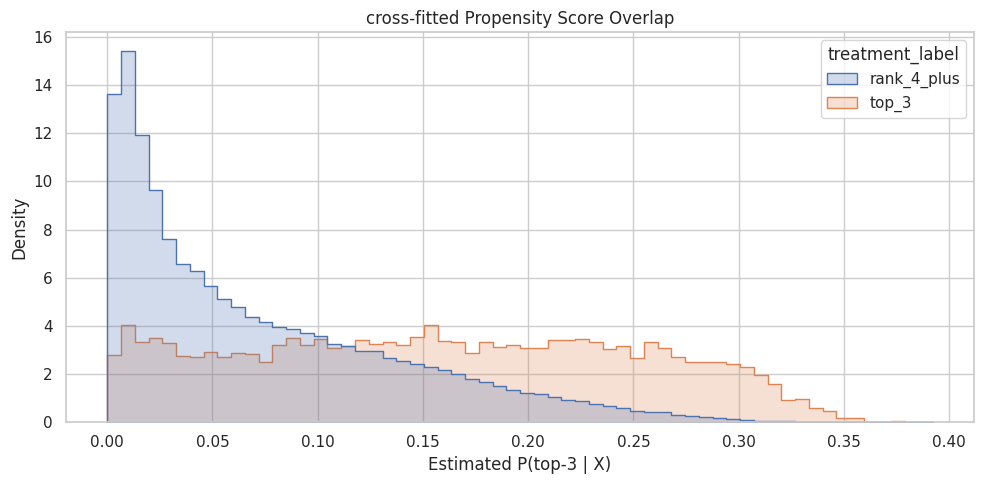

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=model_df,
    x="e_hat",
    hue="treatment_label",
    bins=60,
    stat="density",
    common_norm=False,
    element="step",
)
plt.title("cross-fitted Propensity Score Overlap")
plt.xlabel("Estimated P(top-3 | X)")
plt.ylabel("Density")
plt.tight_layout()

The overlap plot shows whether treated and control rows share comparable propensity-score ranges. Good overlap supports weighting; poor overlap warns that some treated rows have no credible comparison rows, or vice versa.


#### Plot Outcome-Model Treatment Effects

This cell plots the distribution of `mu1_hat - mu0_hat`. This is not the final doubly robust estimate; it is the outcome model's predicted individual-level treatment contrast. It helps us see whether the outcome model thinks the top-3 effect is broadly positive, negative, or concentrated in a small part of the sample.

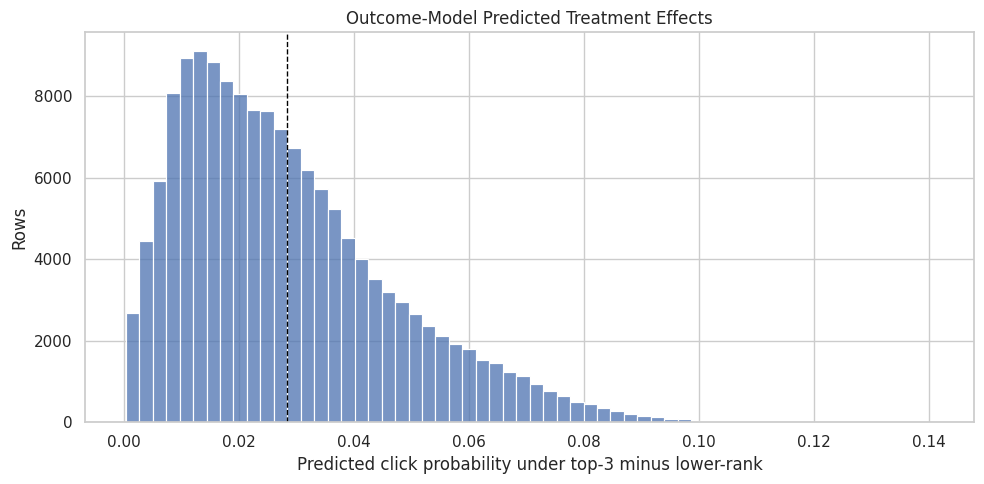

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(model_df["mu_diff_hat"], bins=60)
plt.axvline(model_df["mu_diff_hat"].mean(), color="black", linestyle="--", linewidth=1)
plt.title("Outcome-Model Predicted Treatment Effects")
plt.xlabel("Predicted click probability under top-3 minus lower-rank")
plt.ylabel("Rows")
plt.tight_layout()

The predicted treatment-effect distribution shows how the outcome model expects lift to vary across rows. This is a model-based view of heterogeneity that the AIPW step will combine with observed residual correction.


### AIPW and Doubly Robust Estimate

The augmented inverse propensity weighting (AIPW) score for each row is:

`mu1_hat - mu0_hat + T * (Y - mu1_hat) / e_hat - (1 - T) * (Y - mu0_hat) / (1 - e_hat)`

Where:

- `T` is treatment.
- `Y` is the observed click outcome.
- `e_hat` is the propensity score.
- `mu1_hat` is the predicted outcome under treatment.
- `mu0_hat` is the predicted outcome under control.

The first term, `mu1_hat - mu0_hat`, is the outcome-model contrast. The residual correction terms use observed outcomes and propensity scores to correct the outcome model. This is the double robustness property in action.

#### Compute AIPW Scores

This cell clips propensity scores away from 0 and 1 for numerical stability, then computes one AIPW score per row. The final doubly robust ATE is the average of these scores. The score distribution is also useful for uncertainty estimates and diagnostics.

In [11]:
EPS = 0.01

e = model_df["e_hat"].clip(EPS, 1 - EPS).to_numpy()
mu1 = model_df["mu1_hat"].to_numpy()
mu0 = model_df["mu0_hat"].to_numpy()
t_np = model_df["treatment"].to_numpy()
y_np = model_df["outcome"].to_numpy()

aipw_scores = (mu1 - mu0) + t_np * (y_np - mu1) / e - (1 - t_np) * (y_np - mu0) / (1 - e)
model_df["aipw_score"] = aipw_scores

dr_ate = aipw_scores.mean()
dr_se = aipw_scores.std(ddof=1) / np.sqrt(len(aipw_scores))
dr_ci = (dr_ate - 1.96 * dr_se, dr_ate + 1.96 * dr_se)

pd.Series(
    {
        "dr_ate": dr_ate,
        "standard_error": dr_se,
        "ci_95_lower": dr_ci[0],
        "ci_95_upper": dr_ci[1],
    }
)

dr_ate           0.0111
standard_error   0.0025
ci_95_lower      0.0062
ci_95_upper      0.0161
dtype: float64

The AIPW score combines outcome-model predictions with propensity-weighted residual corrections. This is the key doubly robust object: it can remain consistent if either the propensity model or the outcome model is correctly specified.


#### Inspect AIPW Score Distribution

This cell summarizes the per-row AIPW scores. Extreme values can indicate unstable propensities or model extrapolation, which makes overlap and sensitivity checks important.

In [12]:
model_df["aipw_score"].describe(percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99])

count   150000.0000
mean         0.0111
std          0.9733
min         -8.2176
1%          -1.2288
5%          -0.8844
10%         -0.3209
50%          0.0473
90%          0.1285
95%          0.1622
99%          0.2637
max         99.2251
Name: aipw_score, dtype: float64

The AIPW score distribution checks for extreme influence points. A heavy-tailed score distribution would motivate clipping, sensitivity analysis, or more conservative interpretation. A stable score distribution suggests the estimate is informed across many rows.


#### Compare Naive, IPW, Outcome Regression, And DR

A good causal analysis compares several estimators to understand how sensitive the conclusion is to modeling choices.

- **Naive**: raw top-3 CTR minus lower-ranked CTR.
- **IPW**: uses only the propensity model.
- **Outcome regression**: uses only the outcome model contrast `mean(mu1_hat - mu0_hat)`.
- **Doubly robust / AIPW**: combines outcome regression with IPW residual corrections.

If the adjusted estimators agree directionally, that is reassuring. If they disagree sharply, we need more diagnostics before making product claims.

#### Build Estimate Comparison Table

This cell computes the four estimates side by side. The `absolute_lift` column is the estimated change in click probability. The `relative_lift_vs_control` column expresses that lift relative to the lower-ranked baseline CTR when that comparison is meaningful.

In [13]:
# Build estimate comparison table.
def weighted_mean(values, weights):
    """
    Compute a weighted mean for causal diagnostics.
    
    Idea
    ----
    Use this helper when treated-control averages, covariate summaries, or estimator components need to respect inverse-propensity or stabilized weights.
    
    Parameters
    ----------
    values : object
        Numeric values to summarize.
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Weighted average after aligning values and weights and ignoring missing pairs.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    return np.sum(values * weights) / np.sum(weights)


ipw_weights = np.where(t_np == 1, 1 / e, 1 / (1 - e))
ipw_cap = np.quantile(ipw_weights, 0.99)
ipw_weights_capped = np.clip(ipw_weights, None, ipw_cap)

naive_top3_ctr = model_df.loc[model_df["treatment"] == 1, "outcome"].mean()
naive_lower_ctr = model_df.loc[model_df["treatment"] == 0, "outcome"].mean()

ipw_top3_ctr = weighted_mean(
    model_df.loc[model_df["treatment"] == 1, "outcome"],
    ipw_weights_capped[model_df["treatment"] == 1],
)
ipw_lower_ctr = weighted_mean(
    model_df.loc[model_df["treatment"] == 0, "outcome"],
    ipw_weights_capped[model_df["treatment"] == 0],
)

outcome_regression_ate = model_df["mu_diff_hat"].mean()

comparison = pd.DataFrame(
    [
        {
            "method": "naive",
            "top3_ctr": naive_top3_ctr,
            "lower_rank_ctr": naive_lower_ctr,
            "absolute_lift": naive_top3_ctr - naive_lower_ctr,
            "relative_lift_vs_control": naive_top3_ctr / naive_lower_ctr - 1,
        },
        {
            "method": "ipw_capped",
            "top3_ctr": ipw_top3_ctr,
            "lower_rank_ctr": ipw_lower_ctr,
            "absolute_lift": ipw_top3_ctr - ipw_lower_ctr,
            "relative_lift_vs_control": ipw_top3_ctr / ipw_lower_ctr - 1,
        },
        {
            "method": "outcome_regression",
            "top3_ctr": np.nan,
            "lower_rank_ctr": np.nan,
            "absolute_lift": outcome_regression_ate,
            "relative_lift_vs_control": outcome_regression_ate / naive_lower_ctr,
        },
        {
            "method": "doubly_robust_aipw",
            "top3_ctr": np.nan,
            "lower_rank_ctr": np.nan,
            "absolute_lift": dr_ate,
            "relative_lift_vs_control": dr_ate / naive_lower_ctr,
        },
    ]
)

comparison

,method,top3_ctr,lower_rank_ctr,absolute_lift,relative_lift_vs_control
0,naive,0.1019,0.0341,0.0678,1.9857
1,ipw_capped,0.0544,0.0358,0.0186,0.5190
2,outcome_regression,NaN,NaN,0.0283,0.8300
3,doubly_robust_aipw,NaN,NaN,0.0111,0.3263


The comparison table places naive, adjusted, and model-based estimates side by side. Agreement increases confidence, while large differences reveal how much adjustment changes the raw ranking-position story.


#### Plot Estimate Comparison

This cell visualizes the absolute lift estimates from the comparison table. The chart makes it easy to see whether adjustment shrinks, expands, or reverses the raw top-3 lift. The doubly robust estimate is the main estimate in this notebook.

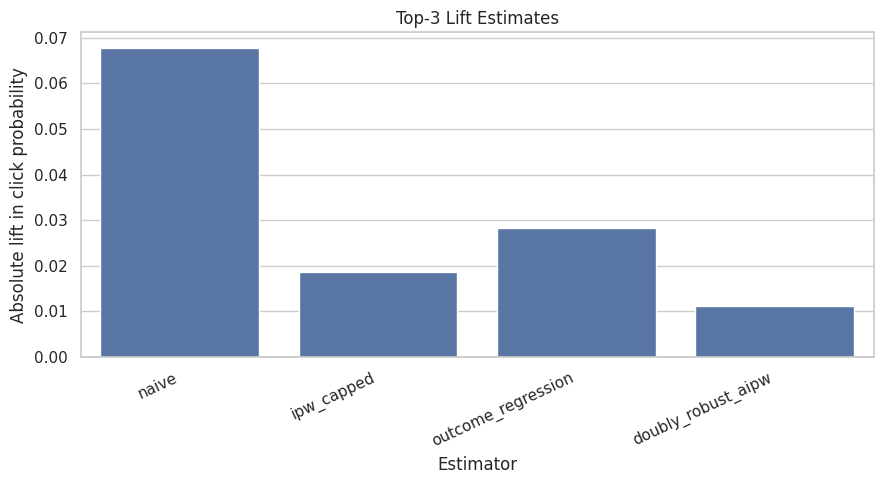

In [14]:
plt.figure(figsize=(9, 5))
sns.barplot(data=comparison, x="method", y="absolute_lift")
plt.axhline(0, color="black", linewidth=1)
plt.title("Top-3 Lift Estimates")
plt.xlabel("Estimator")
plt.ylabel("Absolute lift in click probability")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

The comparison table places naive, adjusted, and model-based estimates side by side. Agreement increases confidence, while large differences reveal how much adjustment changes the raw ranking-position story.


### Uncertainty

The AIPW score gives a convenient standard error using the variation of the per-row scores. This is an influence-function style confidence interval. It treats the cross-fitted nuisance predictions as fixed after training, so it is a practical first uncertainty estimate.

We also compute a lightweight bootstrap over the AIPW scores. This resamples the scores, not the entire model-fitting process, so it is fast and mainly checks that the normal approximation is not wildly misleading.

#### Compute Confidence Intervals

This cell reports the analytic AIPW confidence interval and a score-bootstrap confidence interval. The bootstrap samples rows from the already-computed AIPW scores and recalculates their mean many times.

In [15]:
BOOTSTRAP_REPS = 300
rng = np.random.default_rng(RANDOM_STATE)

bootstrap_estimates = np.empty(BOOTSTRAP_REPS)
for i in range(BOOTSTRAP_REPS):
    idx = rng.integers(0, len(aipw_scores), size=len(aipw_scores))
    bootstrap_estimates[i] = aipw_scores[idx].mean()

bootstrap_ci = np.quantile(bootstrap_estimates, [0.025, 0.975])

uncertainty = pd.DataFrame(
    [
        {
            "method": "aipw_normal_approx",
            "estimate": dr_ate,
            "ci_95_lower": dr_ci[0],
            "ci_95_upper": dr_ci[1],
        },
        {
            "method": "aipw_score_bootstrap",
            "estimate": bootstrap_estimates.mean(),
            "ci_95_lower": bootstrap_ci[0],
            "ci_95_upper": bootstrap_ci[1],
        },
    ]
)

uncertainty

,method,estimate,ci_95_lower,ci_95_upper
0,aipw_normal_approx,0.0111,0.0062,0.0161
1,aipw_score_bootstrap,0.0108,0.0064,0.0157


The confidence intervals add uncertainty to the point estimates. This is important for causal reporting because a useful causal project should discuss both precision and direction.


### Sensitivity to Propensity Clipping

Because AIPW uses inverse propensity terms, estimates can be sensitive to how aggressively we clip propensity scores. This section recomputes the doubly robust estimate with several clipping thresholds.

If the estimate changes dramatically as clipping changes, that signals instability or poor overlap. If estimates are similar across reasonable thresholds, that supports the robustness of the result.

#### Recompute AIPW Under Different Clipping Choices

This cell loops over a few values of `epsilon`, clips propensity scores to `[epsilon, 1 - epsilon]`, and recomputes the AIPW estimate. The output lets us check whether the main result depends heavily on the default `0.01` clipping choice.

In [16]:
sensitivity_rows = []
for eps in [0.001, 0.005, 0.01, 0.02, 0.05]:
    e_eps = model_df["e_hat"].clip(eps, 1 - eps).to_numpy()
    scores_eps = (mu1 - mu0) + t_np * (y_np - mu1) / e_eps - (1 - t_np) * (y_np - mu0) / (1 - e_eps)
    se_eps = scores_eps.std(ddof=1) / np.sqrt(len(scores_eps))
    sensitivity_rows.append(
        {
            "epsilon": eps,
            "dr_ate": scores_eps.mean(),
            "standard_error": se_eps,
            "ci_95_lower": scores_eps.mean() - 1.96 * se_eps,
            "ci_95_upper": scores_eps.mean() + 1.96 * se_eps,
        }
    )

sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity

,epsilon,dr_ate,standard_error,ci_95_lower,ci_95_upper
0,0.0010,0.0125,0.0058,0.0012,0.0238
1,0.0050,0.0113,0.0033,0.0049,0.0178
2,0.0100,0.0111,0.0025,0.0062,0.0161
3,0.0200,0.0122,0.0020,0.0083,0.0160
4,0.0500,0.0156,0.0015,0.0127,0.0185


The AIPW score combines outcome-model predictions with propensity-weighted residual corrections. This is the key doubly robust object: it can remain consistent if either the propensity model or the outcome model is correctly specified.


## Final Takeaways

The doubly robust estimate is an adjusted observational contrast, not a randomized experiment. It is most credible when the propensity model shows usable overlap, the outcome models produce plausible counterfactual click probabilities, and the IPW, outcome-regression, and AIPW estimates tell a broadly consistent story.

The practical result is that top-rank exposure can be evaluated as more than a raw CTR comparison. The final claim should stay bounded by the design: the estimate depends on measured user, item, and context features, and any ranking-policy change still needs online validation before production use.
